# Amazon Fine Food Reviews Sentiment Analysis

## Project Overview

This project focuses on performing Sentiment Analysis on Amazon Fine Food Reviews using Natural Language Processing (NLP) and Transformer-based Deep Learning models.

The main objective of this project is to analyze customer reviews and identify whether the sentiment expressed in the review is Positive, Neutral, or Negative.

In this project, both traditional and modern NLP approaches are used:

- Exploratory Data Analysis (EDA)
- Natural Language Processing (NLP)
- VADER Sentiment Analysis
- RoBERTa Transformer Model
- Hugging Face Transformers Pipeline

The project also compares the performance of VADER and RoBERTa models to understand how transformer-based models outperform traditional lexicon-based approaches in understanding contextual sentiment.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- NLTK
- Hugging Face Transformers
- RoBERTa

## Project Goals

- Analyze customer opinions from reviews
- Perform sentiment classification
- Compare NLP models
- Visualize sentiment patterns
- Understand contextual sentiment analysis using transformers

# About the Dataset

The dataset used in this project is the Amazon Fine Food Reviews dataset.

It contains customer reviews of food products sold on Amazon. The dataset includes information such as:

- Review Text
- Review Summary
- Review Score
- User Information
- Helpfulness Votes
- Review Time

## Important Columns

| Column | Description |
|---|---|
| Score | Rating given by the customer (1–5) |
| Text | Complete customer review |
| Summary | Short summary of the review |
| ProfileName | Reviewer name |
| HelpfulnessNumerator | Number of helpful votes |
| HelpfulnessDenominator | Total votes received |

## Sentiment Interpretation

For sentiment analysis:

- Scores 1–2 → Negative Sentiment
- Score 3 → Neutral Sentiment
- Scores 4–5 → Positive Sentiment

## Dataset Purpose

This dataset is widely used for:
- Sentiment Analysis
- NLP Tasks
- Text Classification
- Opinion Mining
- Transformer-based Learning

# Sentiment Analysis in Python

In this notebook i'll be doing some sentiment analysis in python using two different techniques:
1. VADER (Valence Aware Dictionary and sEntiment Reasoner) - Bag of words approach
2. Roberta Pretrained Model from 🤗
3. Huggingface Pipeline

# Step 1. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
import re
import matplotlib.ticker as mticker


# Step 2. Load Data Set & Basic Info

In [ ]:
df = pd.read_csv('Reviews.csv')
print(f"\nShape        :{df.shape}")
print(f"Columns      :{list(df.columns)}")
print(f"Memory Usage :{df.memory_usage().sum() /1e6:.1f} MB\n")
df.head()


Shape        :(568454, 10)
Columns      :['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']
Memory Usage :45.5 MB



,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [ ]:
print("----Data Types----")
print(df.dtypes)
print("\n----Null Values----")
print(df.isnull().sum())

----Data Types----
Id                         int64
ProductId                 object
UserId                    object
ProfileName               object
HelpfulnessNumerator       int64
HelpfulnessDenominator     int64
Score                      int64
Time                       int64
Summary                   object
Text                      object
dtype: object

----Null Values----
Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64


# Step 3. Data Cleaning

In [ ]:
print(f"Rows before cleaning :{len(df):,}")

# ── Step 1: Drop rows with missing Text or Score ──────────────────
df = df.dropna(subset=['Text','Score'])

# ── Step 2: Convert timestamp → datetime ─────────────────────────
df['Time'] = pd.to_datetime(df['Time'], unit='s')
df['Year'] = df['Time'].dt.year
df['Month'] = df['Time'].dt.month

# ── Step 3: Remove duplicates ───────────────────────────────────
df = df.drop_duplicates(subset=['UserId','ProductId','Text'], keep='first')

# ── Step 4: Remove HTML tags from review text ────────────────────
df['Text']    = df['Text'].apply(lambda x: re.sub(r'<.*?>', ' ', str(x)))
df['Summary'] = df['Summary'].fillna('').apply(lambda x: re.sub(r'<.*?>', ' ', str(x)))

# ── Step 5: Helpfulness ratio ────────────────────────────────────
df['HelpfulnessRatio'] = np.where(
    df['HelpfulnessDenominator'] > 0,
    df['HelpfulnessNumerator'] / df['HelpfulnessDenominator'],
    np.nan
)

# ── Step 6: Review length features ───────────────────────────────
df['ReviewLength']   = df['Text'].str.split().str.len()
df['SummaryLength']  = df['Summary'].str.split().str.len()

# ── Step 7: Create Sentiment label (3-class) ─────────────────────
def score_to_sentiment(score):
    if score >= 4:  return 'Positive'
    elif score == 3: return 'Neutral'
    else:            return 'Negative'

df['Sentiment'] = df['Score'].apply(score_to_sentiment)

# ── Step 8: Encode label ─────────────────────────────────────────
label_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
df['Label'] = df['Sentiment'].map(label_map)

df.reset_index(drop=True, inplace=True)

print(f'Rows after  cleaning : {len(df):,}')
print(f'Removed              : {568454 - len(df):,} rows')
print('\nSentiment distribution:')
print(df['Sentiment'].value_counts())
df.head()

Rows before cleaning :568,454
Rows after  cleaning : 567,145
Removed              : 1,309 rows

Sentiment distribution:
Sentiment
Positive    442869
Negative     81718
Neutral      42558
Name: count, dtype: int64


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Year,Month,HelpfulnessRatio,ReviewLength,SummaryLength,Sentiment,Label
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,2011-04-27,Good Quality Dog Food,I have bought several of the Vitality canned d...,2011,4,1.0,48,4,Positive,2
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,2012-09-07,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,2012,9,NaN,31,3,Negative,0
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,2008-08-18,"""Delight"" says it all",This is a confection that has been around a fe...,2008,8,1.0,94,4,Positive,2
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,2011-06-13,Cough Medicine,If you are looking for the secret ingredient i...,2011,6,1.0,41,2,Negative,0
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,2012-10-21,Great taffy,Great taffy at a great price. There was a wid...,2012,10,NaN,27,2,Positive,2


# Step 4. EDA



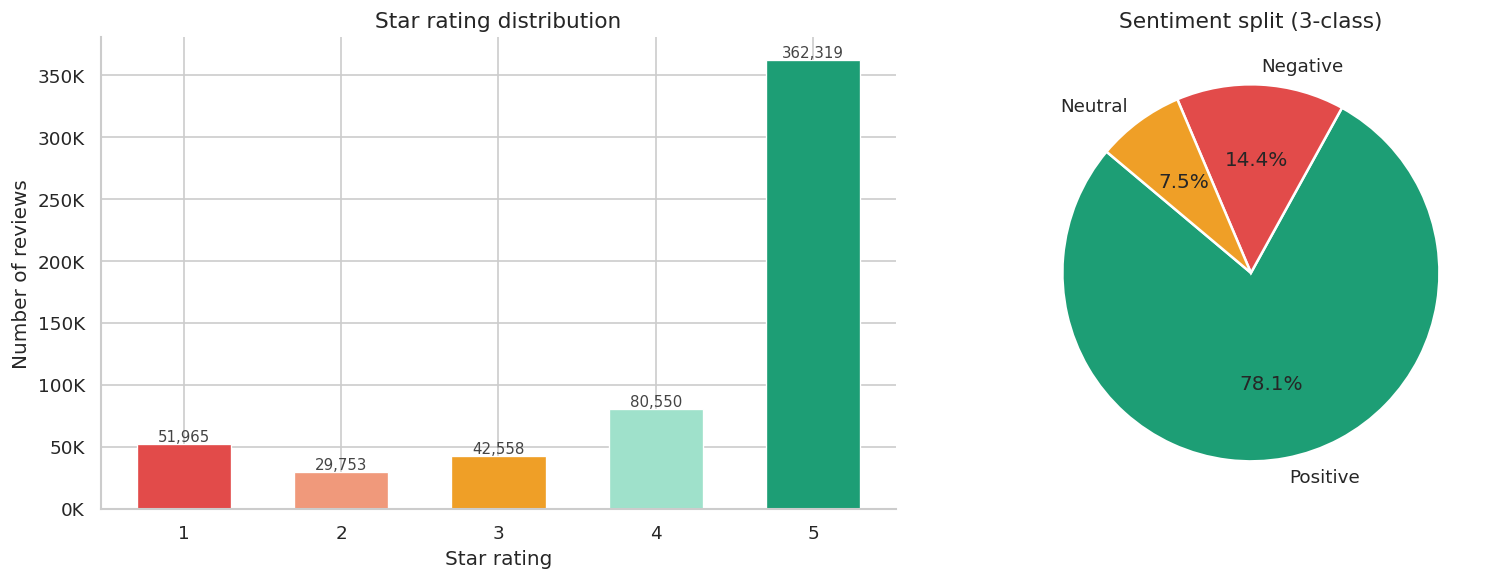

In [ ]:
# ── Plot style ────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
COLORS = {'Positive': '#1D9E75', 'Neutral': '#EF9F27', 'Negative': '#E24B4A'}
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Star rating counts ──────────────────────────────────────
star_counts = df['Score'].value_counts().sort_index()
bar_colors  = ['#E24B4A', '#F0997B', '#EF9F27', '#9FE1CB', '#1D9E75']
axes[0].bar(star_counts.index, star_counts.values, color=bar_colors,
            edgecolor='white', linewidth=0.8, width=0.6)
axes[0].set_title('Star rating distribution', fontsize=13, fontweight='500')
axes[0].set_xlabel('Star rating')
axes[0].set_ylabel('Number of reviews')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
for k, v in star_counts.items():
    axes[0].text(k, v + 2000, f'{v:,}', ha='center', fontsize=9, color='#444')

# ── Right: Sentiment pie chart ────────────────────────────────────
sent_counts = df['Sentiment'].value_counts()
axes[1].pie(
    sent_counts.values,
    labels=sent_counts.index,
    autopct='%1.1f%%',
    colors=[COLORS[s] for s in sent_counts.index],
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Sentiment split (3-class)', fontsize=13, fontweight='500')

plt.tight_layout()
plt.show()

### Review Volume Over Time

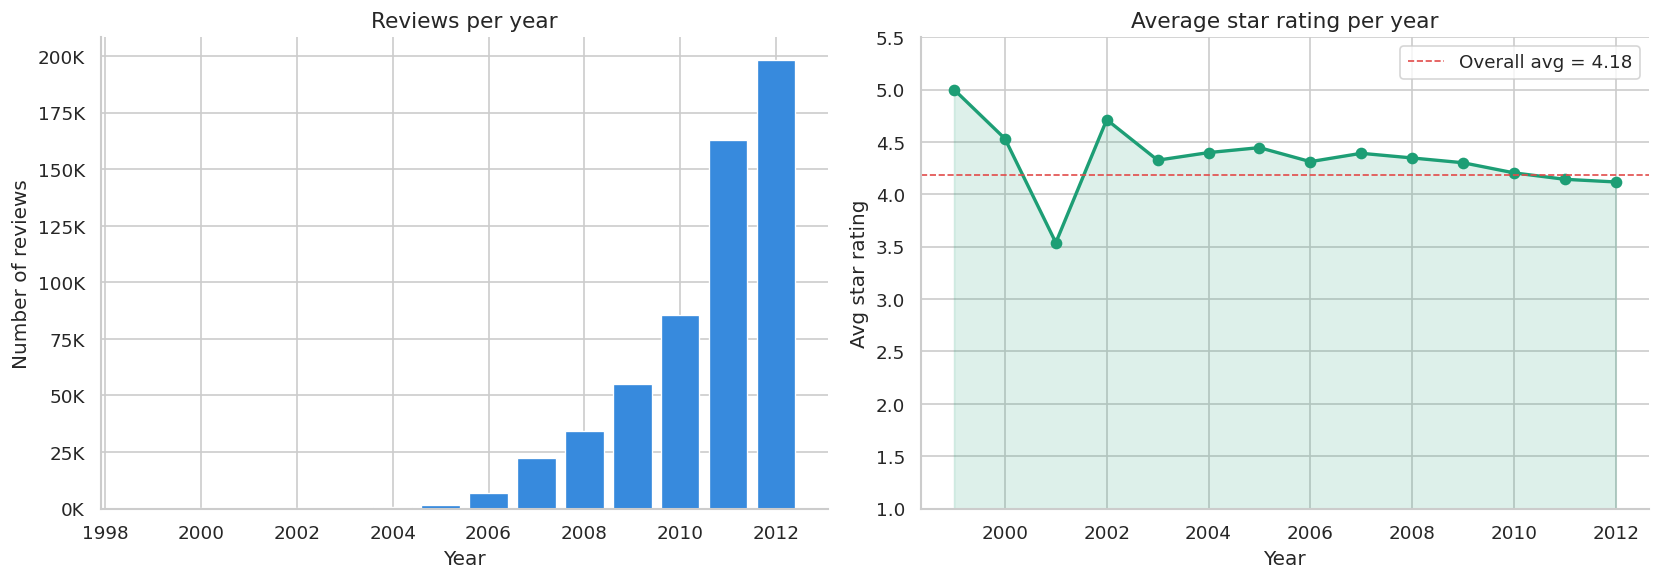

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Reviews per year ─────────────────────────────────────────────
year_counts = df.groupby('Year').size().reset_index(name='Count')
axes[0].bar(year_counts['Year'], year_counts['Count'],
            color='#378ADD', edgecolor='white', linewidth=0.8)
axes[0].set_title('Reviews per year', fontsize=13, fontweight='500')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of reviews')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# ── Avg score per year ────────────────────────────────────────────
avg_score = df.groupby('Year')['Score'].mean().reset_index()
axes[1].plot(avg_score['Year'], avg_score['Score'],
             marker='o', color='#1D9E75', linewidth=2)
axes[1].fill_between(avg_score['Year'], avg_score['Score'],
                      alpha=0.15, color='#1D9E75')
axes[1].set_ylim(1, 5.5)
axes[1].set_title('Average star rating per year', fontsize=13, fontweight='500')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Avg star rating')
axes[1].axhline(df['Score'].mean(), color='#E24B4A',
                linestyle='--', linewidth=1, label=f'Overall avg = {df["Score"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

Overall, the graphs show that **reviews are increasing every year**, meaning more people are giving feedback over time. At the same time, the **average rating stays stable around 4.18**, which means customer satisfaction remains consistently positive despite the growing number of reviews.


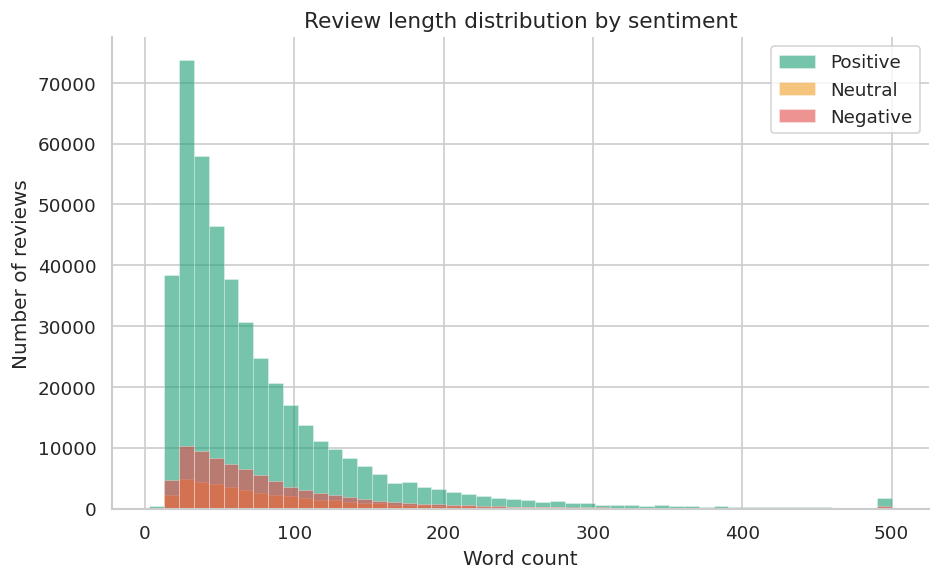

In [ ]:
plt.figure(figsize=(8,5))

for sentiment, color in COLORS.items():
    data = df[df['Sentiment'] == sentiment]['ReviewLength'].clip(upper=500)

    plt.hist(data, bins=50, alpha=0.6, label=sentiment,
             color=color, edgecolor='white', linewidth=0.3)

plt.title('Review length distribution by sentiment', fontsize=13, fontweight='500')
plt.xlabel('Word count')
plt.ylabel('Number of reviews')
plt.legend()

plt.tight_layout()
plt.show()

The histogram shows the distribution of review lengths for positive, neutral, and negative sentiments. Most reviews are short, mainly between 20 and 100 words. Positive reviews are much more frequent and have a wider spread, meaning some positive reviews are very long. Negative and neutral reviews are fewer in number and are generally shorter. As the word count increases, the number of reviews decreases for all sentiment categories. Overall, customers tend to write more detailed reviews when sharing positive experiences about food.

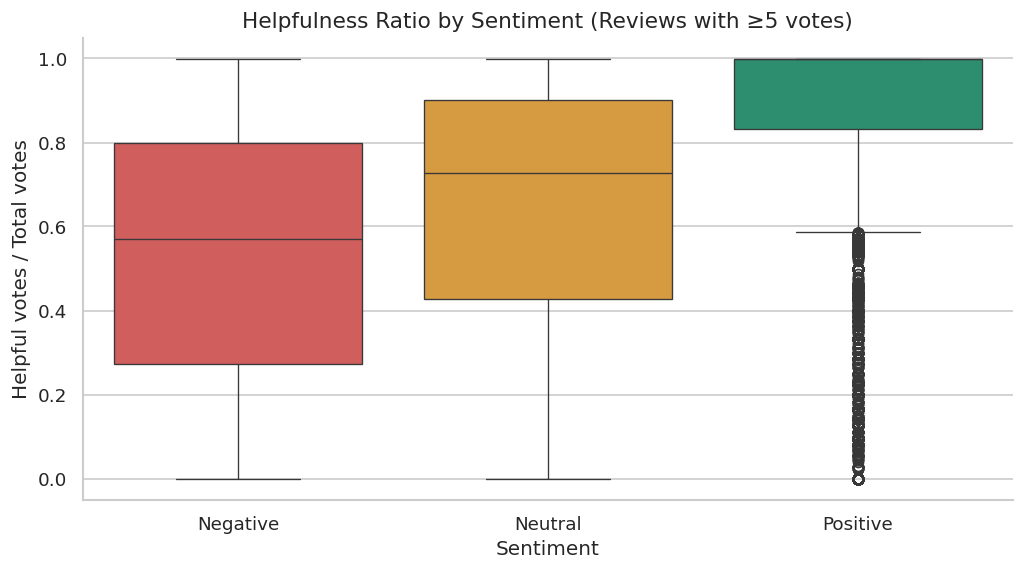

In [ ]:
helpful_df = df[df['HelpfulnessDenominator'] >= 5].copy()

plt.figure(figsize=(10, 5))

sns.boxplot(data=helpful_df, x='Sentiment', y='HelpfulnessRatio',
            order=['Negative', 'Neutral', 'Positive'],hue='Sentiment',
            palette=COLORS, linewidth=0.8)
plt.title('Helpfulness Ratio by Sentiment (Reviews with ≥5 votes)', fontsize=13)
plt.xlabel('Sentiment')
plt.ylabel('Helpful votes / Total votes')

plt.show()

- Positive reviews are the most helpful  
- Neutral reviews have moderate and mixed helpfulness  
- Negative reviews are the least helpful on average  
- There is variation in all groups, but positive reviews are more consistent  

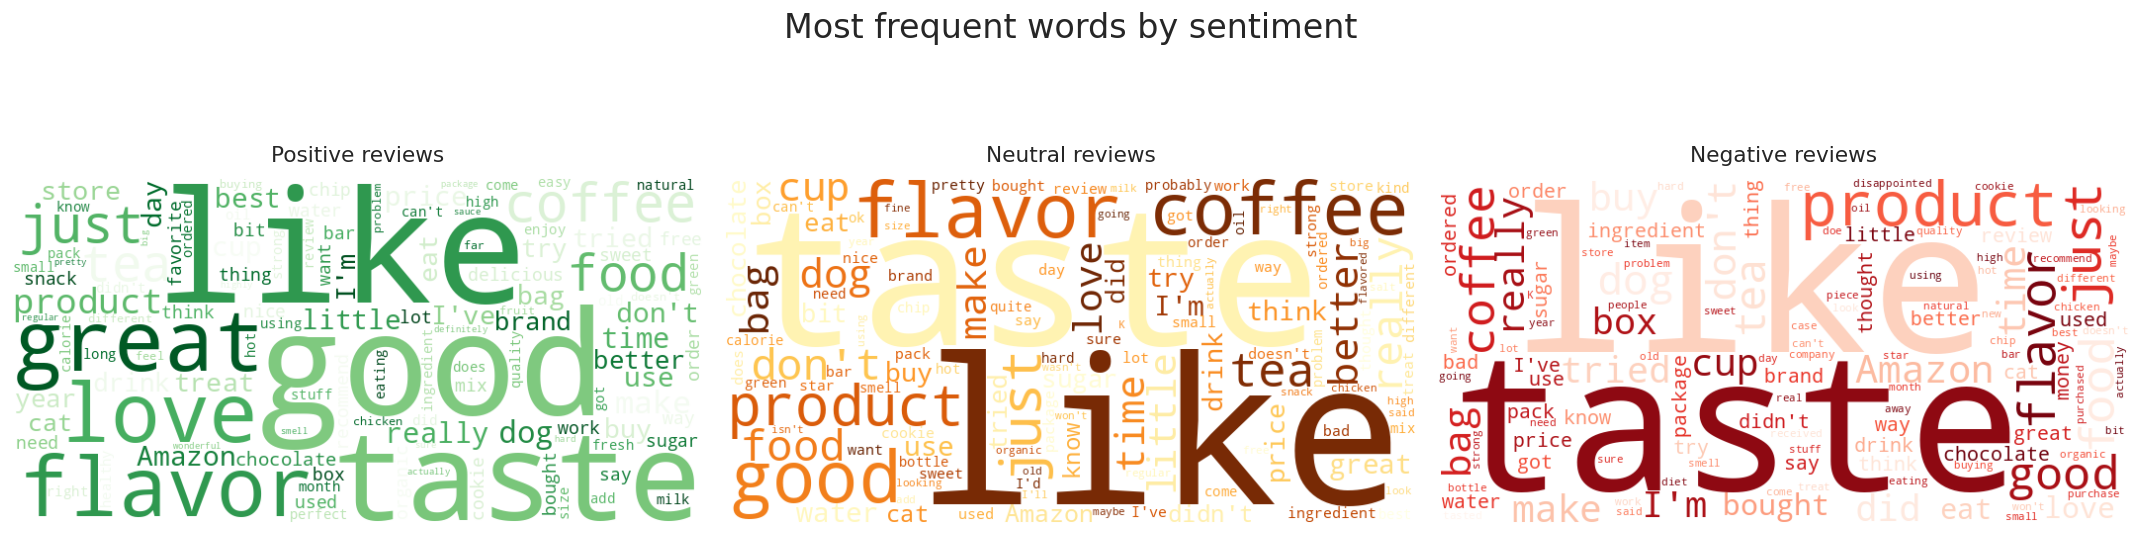

In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
STOP_WORDS = set(ENGLISH_STOP_WORDS)

def make_wordcloud(texts, title, colormap, ax):
    combined = ' '.join(texts)
    wc = WordCloud(
        width=700, height=350,
        background_color='white',
        colormap=colormap,
        stopwords=STOP_WORDS,
        max_words=120,
        collocations=False
    ).generate(combined)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='500', pad=10)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sample to avoid memory issues on 500K rows
for sentiment, cmap, ax in zip(
    ['Positive', 'Neutral', 'Negative'],
    ['Greens', 'YlOrBr', 'Reds'],
    axes
):
    sample = df[df['Sentiment'] == sentiment]['Text'].sample(
        min(5000, len(df[df['Sentiment'] == sentiment])), random_state=42
    ).values
    make_wordcloud(sample, f'{sentiment} reviews', cmap, ax)

plt.suptitle('Most frequent words by sentiment', fontsize=20,
             fontweight='500', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
df = df.head(500)
print(df.shape)

(500, 17)


## Basic NLTK

In [ ]:
example = df['Text'][47]
print(example)

The flavors are good.  However, I do not see any differce between this and Oaker Oats brand - they are both mushy.


In [ ]:
from nltk.tokenize import word_tokenize

tokens = word_tokenize(example, preserve_line=True)
print(tokens[:10])

['The', 'flavors', 'are', 'good.', 'However', ',', 'I', 'do', 'not', 'see']


In [ ]:
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [ ]:
tagged = nltk.pos_tag(tokens)
tagged[:10]

[('The', 'DT'),
 ('flavors', 'NNS'),
 ('are', 'VBP'),
 ('good.', 'JJ'),
 ('However', 'RB'),
 (',', ','),
 ('I', 'PRP'),
 ('do', 'VBP'),
 ('not', 'RB'),
 ('see', 'VB')]

In [ ]:
nltk.download('maxent_ne_chunker')
nltk.download('words')
nltk.download('maxent_ne_chunker_tab')

[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.


True

In [ ]:
entities = nltk.chunk.ne_chunk(tagged)
entities.pprint()

(S
  The/DT
  flavors/NNS
  are/VBP
  good./JJ
  However/RB
  ,/,
  I/PRP
  do/VBP
  not/RB
  see/VB
  any/DT
  differce/NN
  between/IN
  this/DT
  and/CC
  (PERSON Oaker/NNP Oats/NNP)
  brand/NN
  -/:
  they/PRP
  are/VBP
  both/DT
  mushy/NNS
  ./.)


# Step 5. VADER Seniment Scoring

We will use NLTK's `SentimentIntensityAnalyzer` to get the neg/neu/pos scores of the text.

- This uses a "bag of words" approach:
    1. Stop words are removed
    2. each word is scored and combined to a total score.

In [ ]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm import tqdm
sia = SentimentIntensityAnalyzer()

In [ ]:
sia.polarity_scores("I am very sad and disappointed with this product.")

{'neg': 0.53, 'neu': 0.47, 'pos': 0.0, 'compound': -0.7755}

In [ ]:
sia.polarity_scores("I am very happy with this product! It works great and exceeded my expectations.")

{'neg': 0.0, 'neu': 0.567, 'pos': 0.433, 'compound': 0.855}

In [ ]:
sia.polarity_scores(example)

{'neg': 0.0, 'neu': 0.868, 'pos': 0.132, 'compound': 0.4404}

In [ ]:
# Run the polarity score on the entire dataset
res={}
for i, row in tqdm(df.iterrows(), total=len(df)):
    text = row['Text']
    myid = row['Id']
    res[myid] = sia.polarity_scores(text)

100%|██████████| 500/500 [00:00<00:00, 661.65it/s]


In [ ]:
vaders = pd.DataFrame(res).T
vaders = vaders.reset_index().rename(columns={'index': 'Id'})
vaders = vaders.merge(df,how='left')

In [ ]:
vaders.head()

,Id,neg,neu,pos,compound,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,...,Time,Summary,Text,Year,Month,HelpfulnessRatio,ReviewLength,SummaryLength,Sentiment,Label
0,1,0.000,0.695,0.305,0.9441,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,...,2011-04-27,Good Quality Dog Food,I have bought several of the Vitality canned d...,2011,4,1.0,48,4,Positive,2
1,2,0.138,0.862,0.000,-0.5664,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,...,2012-09-07,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,2012,9,NaN,31,3,Negative,0
2,3,0.091,0.754,0.155,0.8265,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,...,2008-08-18,"""Delight"" says it all",This is a confection that has been around a fe...,2008,8,1.0,94,4,Positive,2
3,4,0.000,1.000,0.000,0.0000,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,...,2011-06-13,Cough Medicine,If you are looking for the secret ingredient i...,2011,6,1.0,41,2,Negative,0
4,5,0.000,0.552,0.448,0.9468,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,...,2012-10-21,Great taffy,Great taffy at a great price. There was a wid...,2012,10,NaN,27,2,Positive,2


## Plot VADER results

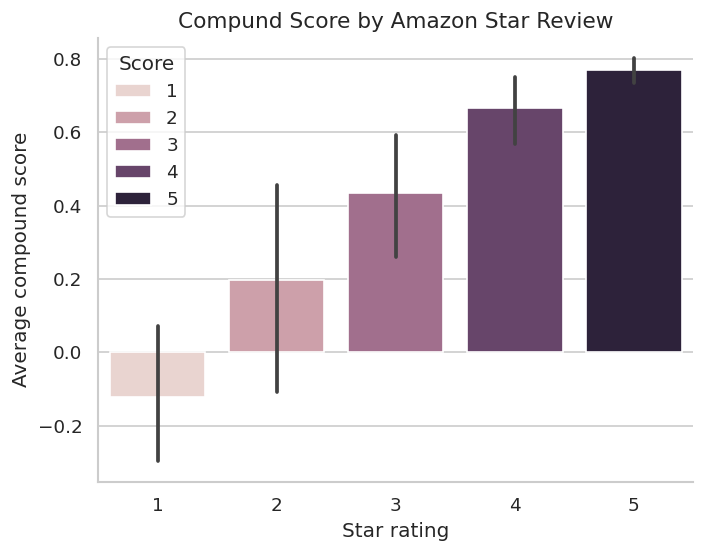

In [ ]:
ax = sns.barplot(data=vaders, x='Score', y='compound',hue='Score')
ax.set_title('Compund Score by Amazon Star Review', fontsize=13, fontweight='500')
ax.set_xlabel('Star rating')
ax.set_ylabel('Average compound score')
plt.show()

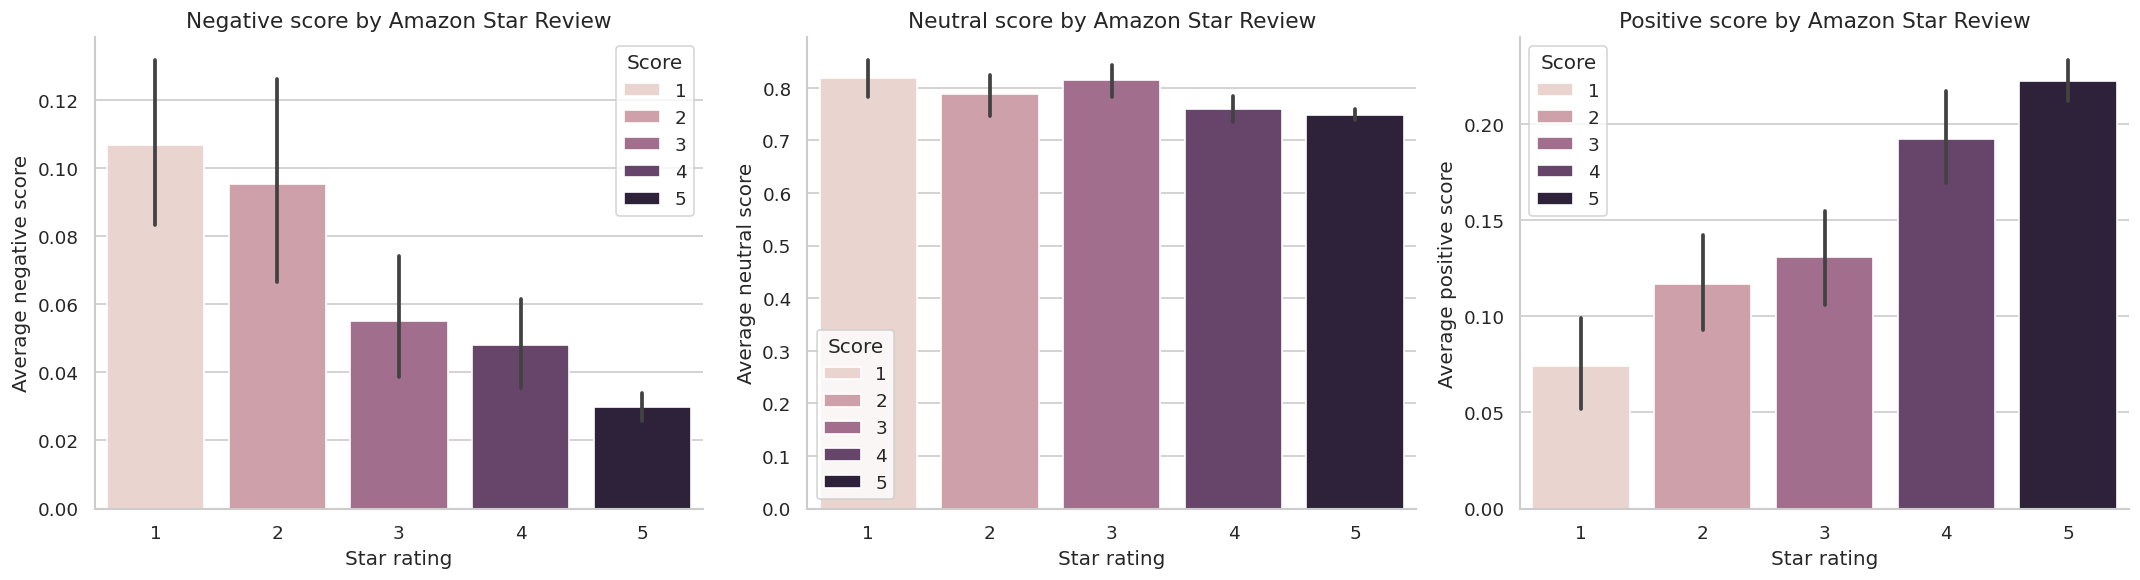

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ax = sns.barplot(data=vaders, x='Score', y='neg',hue='Score', ax=axes[0])
ax.set_title('Negative score by Amazon Star Review', fontsize=13, fontweight='500')
ax.set_xlabel('Star rating')
ax.set_ylabel('Average negative score')
ax = sns.barplot(data=vaders, x='Score', y='neu',hue='Score', ax=axes[1])
ax.set_title('Neutral score by Amazon Star Review', fontsize=13, fontweight='500')
ax.set_xlabel('Star rating')
ax.set_ylabel('Average neutral score')
ax = sns.barplot(data=vaders, x='Score', y='pos',hue='Score', ax=axes[2])
ax.set_title('Positive score by Amazon Star Review', fontsize=13, fontweight='500')
ax.set_xlabel('Star rating')
ax.set_ylabel('Average positive score')
plt.tight_layout()
plt.show()

# Step 6:Roberta Pretrained Model

- Use a model trained of a large corpus of data.
- Transformer model accounts for the words but also the context related to other words.

In [ ]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from scipy.special import softmax

In [ ]:
MODEL = f"cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In the above code, I load a pretrained RoBERTa sentiment analysis model and its tokenizer to convert text into tokens and predict whether the sentiment is positive, negative, or neutral.

In [ ]:
# VADER results on example
print(example)
sia.polarity_scores(example)

The flavors are good.  However, I do not see any differce between this and Oaker Oats brand - they are both mushy.


{'neg': 0.0, 'neu': 0.868, 'pos': 0.132, 'compound': 0.4404}

In [ ]:
# Run for Roberta Model
encoded_text = tokenizer(example, return_tensors='pt')
output = model(**encoded_text)
scores = output[0][0].detach().numpy()
scores = softmax(scores)
scores_dict = {
    'roberta_neg': float(scores[0]),
    'roberta_neu': float(scores[1]),
    'roberta_pos': float(scores[2])
}
print(scores_dict)

{'roberta_neg': 0.16032904386520386, 'roberta_neu': 0.3389703631401062, 'roberta_pos': 0.5007005929946899}


In [ ]:
def polarity_scores_roberta(example):
    encoded_text = tokenizer(example, return_tensors='pt')
    output = model(**encoded_text)
    scores = output[0][0].detach().numpy()
    scores = softmax(scores)
    scores_dict = {
    'roberta_neg': float(scores[0]),
    'roberta_neu': float(scores[1]),
    'roberta_pos': float(scores[2])
    }
    return scores_dict

In [ ]:
res = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    try:
        text = row['Text']
        myid = row['Id']
        vader_result = sia.polarity_scores(text)
        vader_result_rename = {}
        for key, value in vader_result.items():
            vader_result_rename[f"vader_{key}"] = value
        roberta_result = polarity_scores_roberta(text)
        both = {**vader_result_rename, **roberta_result}
        res[myid] = both
    except RuntimeError:
        print(f'Broke for id {myid}')

 17%|█▋        | 83/500 [00:30<02:04,  3.36it/s]

Broke for id 83


 37%|███▋      | 186/500 [01:06<01:36,  3.26it/s]

Broke for id 187


100%|██████████| 500/500 [03:07<00:00,  2.67it/s]


In [ ]:
results_df = pd.DataFrame(res).T
results_df = results_df.reset_index().rename(columns={'index': 'Id'})
results_df = results_df.merge(df, how='left')

## Compare Scores between models

In [ ]:
results_df.columns

Index(['Id', 'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound',
       'roberta_neg', 'roberta_neu', 'roberta_pos', 'ProductId', 'UserId',
       'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator',
       'Score', 'Time', 'Summary', 'Text', 'Year', 'Month', 'HelpfulnessRatio',
       'ReviewLength', 'SummaryLength', 'Sentiment', 'Label'],
      dtype='object')

# Step 7. Combine and compare

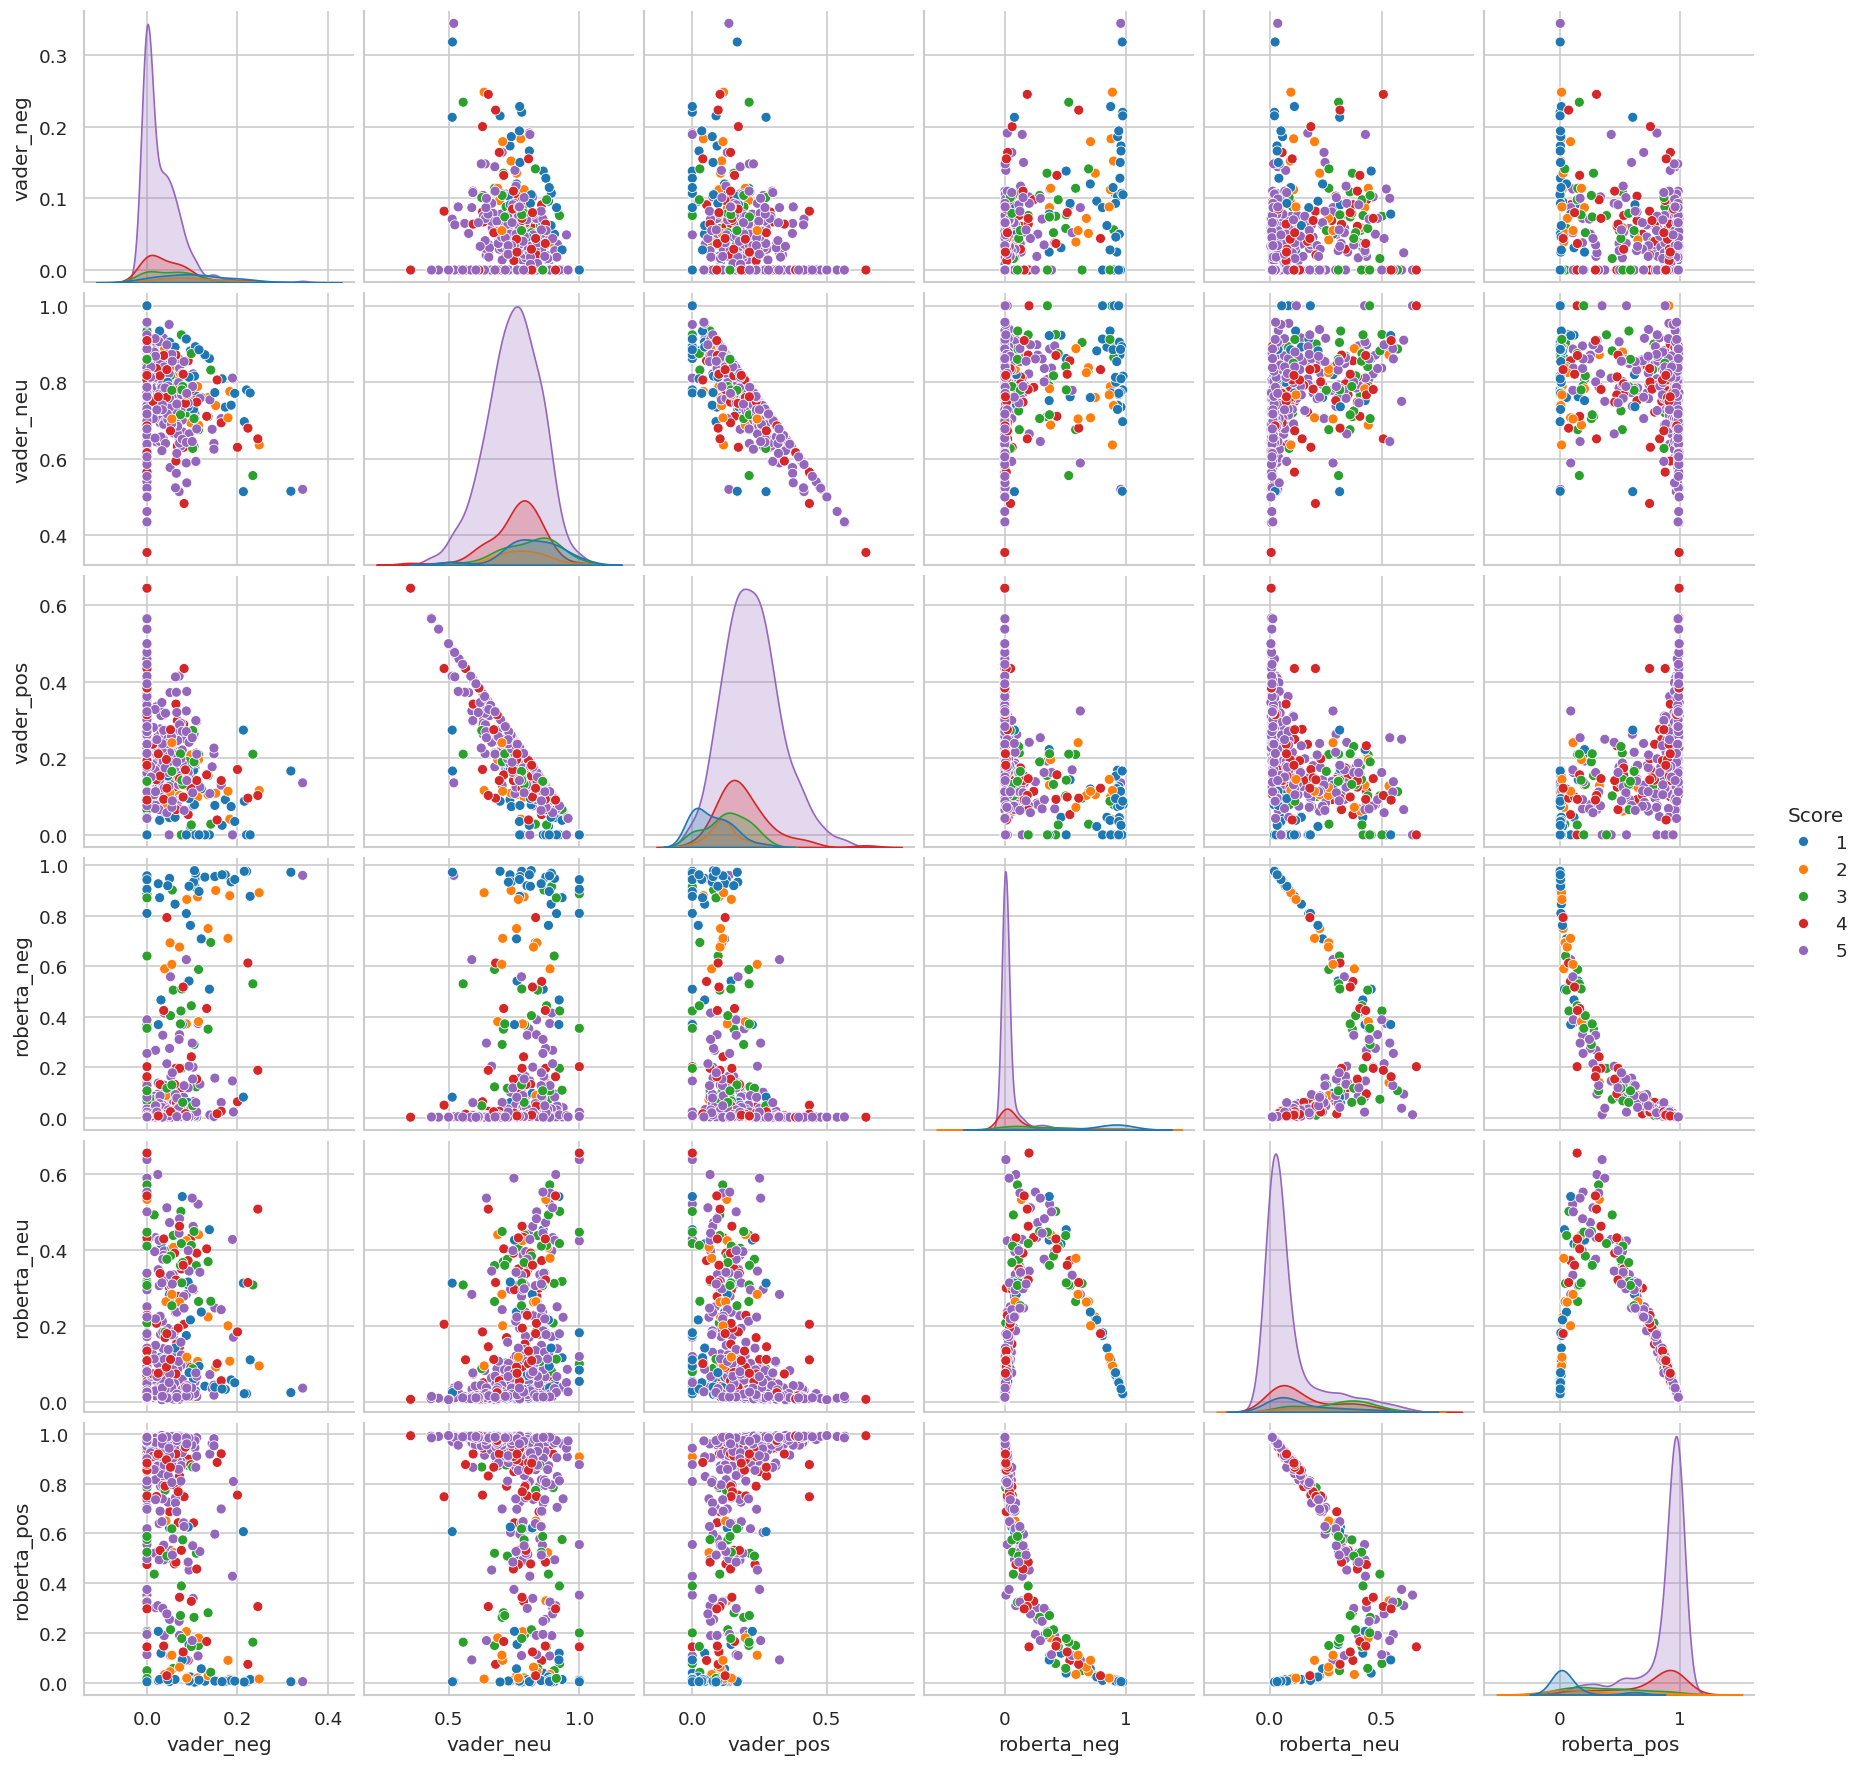

In [ ]:
sns.pairplot(data=results_df,
             vars=['vader_neg', 'vader_neu', 'vader_pos',
                  'roberta_neg', 'roberta_neu', 'roberta_pos'],
            hue='Score',
            palette='tab10')
plt.show()

> The pair plot shows how sentiment scores from VADER and RoBERTa are distributed for food reviews. RoBERTa scores are more concentrated at extreme values (very positive or very negative), which means it gives more confident predictions. In contrast, VADER scores are more spread out, showing moderate and neutral sentiments more often. Positive and negative scores move in opposite directions — when positivity increases, negativity decreases. Reviews with higher ratings (4–5 stars) mostly have high positive scores, while low ratings (1–2 stars) have higher negative scores.


# Step 8: Review Examples:

- Positive 1-Star and Negative 5-Star Reviews

Lets look at some examples where the model scoring and review score differ the most.

### Do RoBERTa and VADER misclassify any 1-star reviews as positive, and how do their predictions compare?

In [ ]:
results_df.query('Score == 1') \
    .sort_values('roberta_pos', ascending=False)['Text'].values[0]

'I felt energized within five minutes, but it lasted for about 45 minutes. I paid $3.99 for this drink. I could have just drunk a cup of coffee and saved my money.'

In [ ]:
results_df.query('Score == 1') \
    .sort_values('vader_pos', ascending=False)['Text'].values[0]

'So we cancelled the order.  It was cancelled without any problem.  That is a positive note...'

### Negative sentiment 5-Star view

In [ ]:
results_df.query('Score == 5') \
    .sort_values('roberta_neg', ascending=False)['Text'].values[0]

'this was sooooo deliscious but too bad i ate em too fast and gained 2 pds! my fault'

In [ ]:
results_df.query('Score == 5') \
    .sort_values('vader_neg', ascending=False)['Text'].values[0]

'this was sooooo deliscious but too bad i ate em too fast and gained 2 pds! my fault'

# Step 9: The Transformers Pipeline
- Quick & easy way to run sentiment predictions

In [ ]:
from transformers import pipeline

sent_pipeline = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [ ]:
sent_pipeline('I love this food!')

[{'label': 'POSITIVE', 'score': 0.9998860359191895}]

In [ ]:
sent_pipeline('Worst food')

[{'label': 'NEGATIVE', 'score': 0.9998007416725159}]

## Project Conclusion

In this project, Sentiment Analysis was performed on Amazon Fine Food Reviews using both traditional NLP techniques and transformer-based deep learning models.

The project included:
- Data Cleaning
- Exploratory Data Analysis (EDA)
- NLP Preprocessing
- VADER Sentiment Analysis
- RoBERTa Transformer Model
- Hugging Face Transformers Pipeline

## Results of VADER Model

The VADER model successfully identified positive, neutral, and negative sentiments from customer reviews. It performed well on simple and straightforward reviews and provided fast sentiment predictions using rule-based analysis.

However, VADER showed limitations in understanding:
- Context
- Sarcasm
- Mixed emotions
- Complex sentence structures

## Results of RoBERTa Model

The RoBERTa transformer model produced more accurate and context-aware sentiment predictions compared to VADER.

It was better at:
- Understanding sentence meaning
- Handling complex reviews
- Detecting contextual sentiment
- Capturing emotional intensity

The predictions from RoBERTa were more confident and better separated across sentiment classes.

## Hugging Face Transformers

The Hugging Face transformers pipeline made it easier to perform advanced sentiment analysis using pretrained deep learning models.

It provided:
- Easy implementation
- Fast inference
- Powerful pretrained transformer models
- Real-world NLP application support

## Key Findings

- Most reviews in the dataset were positive.
- Transformer models performed better than traditional rule-based methods.
- RoBERTa handled contextual sentiment more effectively than VADER.
- NLP and transformer models are highly useful for real-world customer feedback analysis.

## Overall Conclusion

This project demonstrated how Natural Language Processing and Transformer-based models can be used to analyze customer opinions and classify sentiments effectively.

The comparison between VADER and RoBERTa showed that modern transformer models provide more accurate and reliable sentiment analysis results, especially for complex text data.